In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
NVIDIA GeForce RTX 4090


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, random_split
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- TRANSFORMATIONS ---
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- DATASET STREAMING ---
class StreamingCompCarsDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {}
        self.idx_to_class = {}
        self._build_index_only()  # on ne charge pas les images en mémoire
    
    def _build_index_only(self):
        print("Construction de l'index du dataset...")
        image_dir = os.path.join(self.root_dir, "image")
        
        for make_id in os.listdir(image_dir):
            make_path = os.path.join(image_dir, make_id)
            if not os.path.isdir(make_path):
                continue
            
            for model_id in os.listdir(make_path):
                model_path = os.path.join(make_path, model_id)
                if not os.path.isdir(model_path):
                    continue
                
                class_name = f"make{make_id}_model{model_id}"
                if class_name not in self.class_to_idx:
                    self.class_to_idx[class_name] = len(self.class_to_idx)
                    self.idx_to_class[len(self.idx_to_class)] = class_name
                
                class_idx = self.class_to_idx[class_name]
                
                for root, _, files in os.walk(model_path):
                    for file in files:
                        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                            self.image_paths.append((os.path.join(root, file), class_idx))
        
        print(f"Index construit: {len(self.image_paths)} images, {len(self.class_to_idx)} classes")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path, label = self.image_paths[idx]
        
        try:
            image = plt.imread(img_path)
            
            if len(image.shape) == 2:
                image = np.stack([image] * 3, axis=-1)
            elif image.shape[2] == 4:
                image = image[:, :, :3]
            
            if self.transform:
                image = self.transform(image)
            
            return image, label
            
        except Exception as e:
            print(f"Erreur chargement {img_path}: {e}")
            return torch.zeros(3, 224, 224), label

# --- CREATION DU DATASET ---
compcars_root = "dataset"
print(f"Création du dataset depuis: {compcars_root}")

if not os.path.exists(compcars_root):
    print(f"ERREUR: Le dossier {compcars_root} n'existe pas!")
    print("Contenu du répertoire courant:", os.listdir("."))
else:
    print("Contenu du dossier dataset:", os.listdir(compcars_root))
    
    # Dataset en streaming
    full_dataset = StreamingCompCarsDataset(compcars_root, transform=train_transform)
    
    print(f"Nombre total de classes: {len(full_dataset.class_to_idx)}")
    print(f"Nombre total d'images: {len(full_dataset)}")
    
    # --- SPLIT TRAIN/VAL ---
    val_size = int(0.2 * len(full_dataset))
    train_size = len(full_dataset) - val_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    
    # DataLoaders avec réglages pour éviter les bus error
    batch_size = 64
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=12,  # réduire le nombre de workers
        pin_memory=True,
        persistent_workers=False  # éviter les crashs shm
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=12,
        pin_memory=True
    )
    
    # --- MODÈLE ---
    num_classes = len(full_dataset.class_to_idx)
    print(f"\nConfiguration du modèle pour {num_classes} classes...")
    
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)
    
    # --- ENTRAÎNEMENT (test) ---
    print("\nDémarrage de l'entraînement...")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=2e-4)
    
    num_epochs = 50
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / train_size
        epoch_acc = running_corrects.double() / train_size
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}")


Using device: cuda
Création du dataset depuis: dataset
Contenu du dossier dataset: ['image', 'label', 'misc', 'part', 'train_test_split']
Construction de l'index du dataset...
Index construit: 136726 images, 1716 classes
Nombre total de classes: 1716
Nombre total d'images: 136726

Configuration du modèle pour 1716 classes...

Démarrage de l'entraînement...
Epoch 1/50 - Loss: 5.1660, Acc: 0.1361
Epoch 2/50 - Loss: 2.3124, Acc: 0.5136
Epoch 3/50 - Loss: 1.2128, Acc: 0.7250
Epoch 4/50 - Loss: 0.7458, Acc: 0.8234
Epoch 5/50 - Loss: 0.5173, Acc: 0.8726
Epoch 6/50 - Loss: 0.3860, Acc: 0.9021
Epoch 7/50 - Loss: 0.3051, Acc: 0.9209
Epoch 8/50 - Loss: 0.2498, Acc: 0.9337
Epoch 9/50 - Loss: 0.2060, Acc: 0.9443
Epoch 10/50 - Loss: 0.1864, Acc: 0.9493
Epoch 11/50 - Loss: 0.1559, Acc: 0.9566
Epoch 12/50 - Loss: 0.1483, Acc: 0.9583
Epoch 13/50 - Loss: 0.1297, Acc: 0.9640
Epoch 14/50 - Loss: 0.1248, Acc: 0.9647
Epoch 15/50 - Loss: 0.1162, Acc: 0.9667
Epoch 16/50 - Loss: 0.1061, Acc: 0.9695
Epoch 17/5

Nombre de modèles dans le .mat : 2004
Nombre total de classes extraites : 1716
Exemples des 50 premières classes : ['ABT A3', 'ABT A4', 'ABT A5', 'ABT A8', 'ABT A6', 'ABT Q7', 'ABT TT', 'ABT A7', 'ABT Q3', 'ABT Q5', 'ABT RS 4', 'ABT A1', 'BAC Mono', 'Knight XV', 'DS 5', 'DS 6', 'DS 5LS', 'DS 3', 'DS Wild Rubis', 'DS 9', 'DS 4', 'Dokker', 'Duster', 'Logan', 'Sandero', 'Lodgy', 'Atlantic', 'Surf', 'Latigo', 'Tramonto', 'Karma', 'GMC3500', 'Yukon', 'Terrain', 'Sierra', 'Acadia', 'GMC CANYON', 'Savana', 'Apollo', 'Explosion', 'Tornante', 'Venom GT', 'Venom F5', 'VelociRaptor', 'Vulcano', 'Grand Cherokee SRT', 'Wrangler', 'Compass', 'Cherokee', 'Patriot']
Nombre total de classes pour l'évaluation : 1716
Évaluation du modèle sur l'ensemble de validation...

MÉTRIQUES DE PERFORMANCE
Accuracy: 0.8845
Precision: 0.8977
Recall: 0.8845
F1-Score: 0.8840

RAPPORT DE CLASSIFICATION (20 premières classes présentes)
               precision    recall  f1-score   support

       ABT A3     0.6667    0.

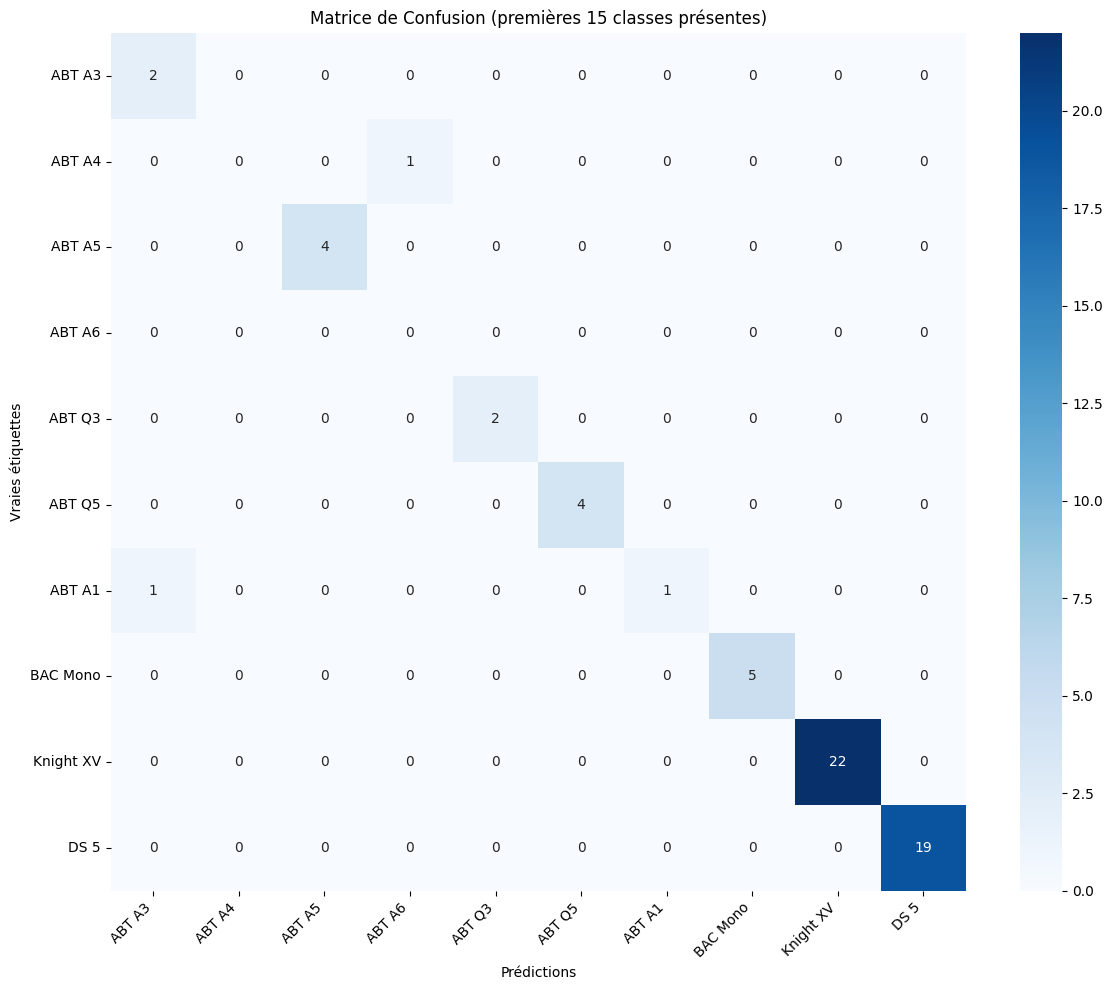


ANALYSE PAR CLASSE (Top 20)
Top 20 des classes les mieux classées (support ≥ 5):
              Class  Accuracy  Support
               DS 9       1.0       22
               DS 4       1.0       20
             Duster       1.0        6
            Sandero       1.0       14
              Lodgy       1.0        6
              Karma       1.0       10
            Terrain       1.0       17
         GMC CANYON       1.0       12
             Apollo       1.0        6
     Grand Cherokee       1.0       17
                MG3       1.0       22
    MINI COUNTRYMAN       1.0       20
       MINI PACEMAN       1.0       21
             MINI E       1.0       16
           MINI JCW       1.0        6
MINI JCW COUNTRYMAN       1.0       10
     MINI JCW COUPE       1.0        9
          Noble M14       1.0        6
          Noble M15       1.0        7
          Noble M12       1.0       26

Top 20 des classes les moins bien classées (support ≥ 5):
              Class  Accuracy  Support
 

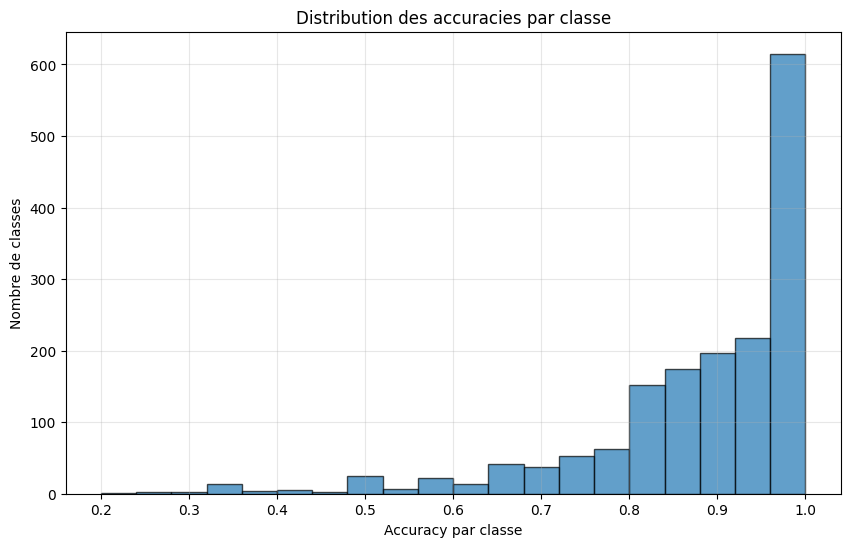

Moyenne accuracy par classe: 0.8855
Médiane accuracy par classe: 0.9200
Nombre de classes avec accuracy > 0.8: 1322
Nombre de classes avec accuracy < 0.2: 0

ANALYSE DES ERREURS
Taux d'erreur global: 0.1155

Top 20 des classes avec le plus d'erreurs:
                    Class  Errors  Support  Error_Rate
             Fengshen S30      14       30    0.466667
                KIA venga      14       22    0.636364
               Aveo sedan      12       22    0.545455
                   DS 5LS      12       28    0.428571
                 Quick V5      12       23    0.521739
               New Carens      12       24    0.500000
                 BAW C90L      11       34    0.323529
        Range Rover Sport      11       25    0.440000
Octavia RS abroad version      11       30    0.366667
              Zhishang XT      11       16    0.687500
              Acura SUV-X      11       24    0.458333
                  Haval E      11       19    0.578947
     AC Schnitzer 6 Class      10 

In [2]:
# --- IMPORTS ---
import os
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torchvision import datasets
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

# --- 1. CHEMINS VERS LE DATASET ET LE .MAT ---
dataset_path = "dataset/image"           # dossier contenant les dossiers 1 à 163
mat_path = "dataset/misc/make_model_name.mat"

# --- 2. CHARGER LES NOMS DE MODÈLE ---
data = scipy.io.loadmat(mat_path)
model_raw = data['model_names']

def extract_model_names(model_raw):
    model_list = []
    for m in model_raw:
        try:
            model_name = str(m[0][0])
            model_list.append(model_name)
        except:
            try:
                model_name = str(m[0])
                model_list.append(model_name)
            except:
                continue
    return model_list

model_list = extract_model_names(model_raw)
print(f"Nombre de modèles dans le .mat : {len(model_list)}")

# --- 3. EXTRACTION EN PROFONDEUR DE TOUTES LES CLASSES ---
all_class_ids = []
all_class_names = []

for folder1 in sorted(os.listdir(dataset_path), key=int):
    folder1_path = os.path.join(dataset_path, folder1)
    if os.path.isdir(folder1_path):
        for subfolder in sorted(os.listdir(folder1_path)):
            subfolder_path = os.path.join(folder1_path, subfolder)
            if os.path.isdir(subfolder_path):
                class_id = int(subfolder) - 1  # Index Python
                all_class_ids.append(class_id)
                all_class_names.append(model_list[class_id])

print(f"Nombre total de classes extraites : {len(all_class_names)}")
print("Exemples des 50 premières classes :", all_class_names[:50])

# --- 4. CHARGER LE DATASET AVEC IMAGEFOLDER ---
dataset = datasets.ImageFolder(dataset_path)
class_to_idx = dataset.class_to_idx

# --- 5. RECONSTRUIRE LES NOMS LISIBLES DES CLASSES ---
# Remplacer les dossiers cryptiques par les noms de modèles
class_names = all_class_names
print(f"Nombre total de classes pour l'évaluation : {len(class_names)}")

# --- 6. FONCTION D'ÉVALUATION DU MODÈLE ---
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return all_labels, all_preds, all_probs

# --- 7. ÉVALUATION SUR L'ENSEMBLE DE VALIDATION ---
print("Évaluation du modèle sur l'ensemble de validation...")
true_labels, pred_labels, probs = evaluate_model(model, val_loader, device)

# --- 8. MÉTRIQUES GLOBALES ---
accuracy = accuracy_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels, average='weighted', zero_division=0)
recall = recall_score(true_labels, pred_labels, average='weighted', zero_division=0)
f1 = f1_score(true_labels, pred_labels, average='weighted', zero_division=0)

print("\n" + "="*50)
print("MÉTRIQUES DE PERFORMANCE")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# --- 9. RAPPORT DE CLASSIFICATION POUR LES 20 PREMIÈRES CLASSES PRÉSENTES ---
first_n_classes = 20
selected_indices = [i for i, label in enumerate(true_labels) if label < first_n_classes]

if selected_indices:
    selected_true = [true_labels[i] for i in selected_indices]
    selected_pred = [pred_labels[i] for i in selected_indices]

    unique_labels = np.unique(selected_true)
    unique_class_names = [class_names[i] for i in unique_labels]

    report = classification_report(
        selected_true,
        selected_pred,
        labels=unique_labels,
        target_names=unique_class_names,
        zero_division=0,
        digits=4
    )
    print("\n" + "="*50)
    print("RAPPORT DE CLASSIFICATION (20 premières classes présentes)")
    print("="*50)
    print(report)
else:
    print("Aucun échantillon dans les 20 premières classes.")

# --- 10. MATRICE DE CONFUSION POUR LES 15 PREMIÈRES CLASSES PRÉSENTES ---
max_display_classes = 15
filtered_indices = [i for i, label in enumerate(true_labels) if label < max_display_classes]
filtered_true = [true_labels[i] for i in filtered_indices]
filtered_pred = [pred_labels[i] for i in filtered_indices]

if filtered_true:
    unique_labels_cm = np.unique(filtered_true)
    unique_class_names_cm = [class_names[i] for i in unique_labels_cm]

    cm = confusion_matrix(filtered_true, filtered_pred, labels=unique_labels_cm)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, 
                annot=True, fmt='d', cmap='Blues',
                xticklabels=unique_class_names_cm,
                yticklabels=unique_class_names_cm)
    plt.title(f'Matrice de Confusion (premières {max_display_classes} classes présentes)')
    plt.xlabel('Prédictions')
    plt.ylabel('Vraies étiquettes')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Pas assez d'échantillons pour la matrice de confusion.")

# --- 4. TOP 20 DES CLASSES LES MIEUX ET MOINS BIEN CLASSÉES ---
print("\n" + "="*50)
print("ANALYSE PAR CLASSE (Top 20)")
print("="*50)

class_accuracy = {}
class_support = {}

for class_idx in range(len(class_names)):
    class_mask = np.array(true_labels) == class_idx
    support = np.sum(class_mask)
    class_support[class_idx] = support
    
    if support > 0:
        class_acc = np.mean(np.array(pred_labels)[class_mask] == class_idx)
        class_accuracy[class_idx] = class_acc
    else:
        class_accuracy[class_idx] = 0

accuracy_data = []
for class_idx in range(len(class_names)):
    if class_support[class_idx] > 0:
        accuracy_data.append({
            'Class': class_names[class_idx],
            'Accuracy': class_accuracy[class_idx],
            'Support': class_support[class_idx]
        })

accuracy_df = pd.DataFrame(accuracy_data)

print("Top 20 des classes les mieux classées (support ≥ 5):")
top20 = accuracy_df[accuracy_df['Support'] >= 5].nlargest(20, 'Accuracy')
print(top20.to_string(index=False))

print("\nTop 20 des classes les moins bien classées (support ≥ 5):")
bottom20 = accuracy_df[accuracy_df['Support'] >= 5].nsmallest(20, 'Accuracy')
print(bottom20.to_string(index=False))

# --- 5. DISTRIBUTION GLOBALE DES PERFORMANCES ---
print("\n" + "="*50)
print("DISTRIBUTION GLOBALE DES ACCURACIES PAR CLASSE")
print("="*50)

plt.figure(figsize=(10, 6))
accuracies = [acc for acc in class_accuracy.values() if acc > 0]
plt.hist(accuracies, bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Accuracy par classe')
plt.ylabel('Nombre de classes')
plt.title('Distribution des accuracies par classe')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Moyenne accuracy par classe: {np.mean(accuracies):.4f}")
print(f"Médiane accuracy par classe: {np.median(accuracies):.4f}")
print(f"Nombre de classes avec accuracy > 0.8: {np.sum(np.array(accuracies) > 0.8)}")
print(f"Nombre de classes avec accuracy < 0.2: {np.sum(np.array(accuracies) < 0.2)}")

# --- 6. ANALYSE DES ERREURS ---
print("\n" + "="*50)
print("ANALYSE DES ERREURS")
print("="*50)

error_rate = 1 - accuracy
print(f"Taux d'erreur global: {error_rate:.4f}")

error_counts = {}
for true_label, pred_label in zip(true_labels, pred_labels):
    if true_label != pred_label:
        error_counts[true_label] = error_counts.get(true_label, 0) + 1

error_df = pd.DataFrame([
    {'Class': class_names[class_idx], 'Errors': count, 'Support': class_support[class_idx]}
    for class_idx, count in error_counts.items()
])

if not error_df.empty:
    error_df['Error_Rate'] = error_df['Errors'] / error_df['Support']
    print("\nTop 20 des classes avec le plus d'erreurs:")
    print(error_df.nlargest(20, 'Errors').to_string(index=False))
    
    print("\nTop 20 des classes avec le taux d'erreur le plus élevé (support ≥ 10):")
    high_error = error_df[error_df['Support'] >= 10].nlargest(20, 'Error_Rate')
    print(high_error.to_string(index=False))

# --- 7. SAUVEGARDE DES RÉSULTATS ---
print("\n" + "="*50)
print("SAUVEGARDE DES RÉSULTATS")
print("="*50)

global_metrics = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'num_classes': len(class_names),
    'total_samples': len(true_labels),
    'error_rate': error_rate
}

accuracy_df.to_csv('resultats_detailles.csv', index=False)
print("Résultats détaillés sauvegardés dans 'resultats_detailles.csv'")

print("\n✅ Évaluation terminée!")
print(f"Performance globale: {accuracy:.2%} de précision")
print(f"Le modèle performe bien sur {len(top20)} classes et moins bien sur {len(bottom20)} classes")


# --- 11. ANALYSE PAR CLASSE, DISTRIBUTION, ERREURS ET SAUVEGARDE ---
# Tu peux réutiliser la logique de ton script original ici
# Les noms de classes sont déjà les noms lisibles de modèles


In [1]:
## Modèle couche RelU

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, random_split
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- TRANSFORMATIONS ---
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- DATASET STREAMING ---
class StreamingCompCarsDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {}
        self.idx_to_class = {}
        self._build_index_only()  # on ne charge pas les images en mémoire
    
    def _build_index_only(self):
        print("Construction de l'index du dataset...")
        image_dir = os.path.join(self.root_dir, "image")
        
        for make_id in os.listdir(image_dir):
            make_path = os.path.join(image_dir, make_id)
            if not os.path.isdir(make_path):
                continue
            
            for model_id in os.listdir(make_path):
                model_path = os.path.join(make_path, model_id)
                if not os.path.isdir(model_path):
                    continue
                
                class_name = f"make{make_id}_model{model_id}"
                if class_name not in self.class_to_idx:
                    self.class_to_idx[class_name] = len(self.class_to_idx)
                    self.idx_to_class[len(self.idx_to_class)] = class_name
                
                class_idx = self.class_to_idx[class_name]
                
                for root, _, files in os.walk(model_path):
                    for file in files:
                        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                            self.image_paths.append((os.path.join(root, file), class_idx))
        
        print(f"Index construit: {len(self.image_paths)} images, {len(self.class_to_idx)} classes")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path, label = self.image_paths[idx]
        
        try:
            image = plt.imread(img_path)
            
            if len(image.shape) == 2:
                image = np.stack([image] * 3, axis=-1)
            elif image.shape[2] == 4:
                image = image[:, :, :3]
            
            if self.transform:
                image = self.transform(image)
            
            return image, label
            
        except Exception as e:
            print(f"Erreur chargement {img_path}: {e}")
            return torch.zeros(3, 224, 224), label

# --- CREATION DU DATASET ---
compcars_root = "dataset"
print(f"Création du dataset depuis: {compcars_root}")

if not os.path.exists(compcars_root):
    print(f"ERREUR: Le dossier {compcars_root} n'existe pas!")
    print("Contenu du répertoire courant:", os.listdir("."))
else:
    print("Contenu du dossier dataset:", os.listdir(compcars_root))
    
    # Dataset en streaming
    full_dataset = StreamingCompCarsDataset(compcars_root, transform=train_transform)
    
    print(f"Nombre total de classes: {len(full_dataset.class_to_idx)}")
    print(f"Nombre total d'images: {len(full_dataset)}")
    
    # --- SPLIT TRAIN/VAL ---
    val_size = int(0.2 * len(full_dataset))
    train_size = len(full_dataset) - val_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    
    # DataLoaders avec réglages pour éviter les bus error
    batch_size = 64
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=12,  # réduire le nombre de workers
        pin_memory=True,
        persistent_workers=False  # éviter les crashs shm
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=8,
        pin_memory=True
    )
    
    # --- MODÈLE ---
     # Taille des features de sortie de ResNet18
    num_classes = len(full_dataset.class_to_idx)
    print(f"\nConfiguration du modèle pour {num_classes} classes...")
    
    model = models.resnet50(pretrained=True)
    in_features = model.fc.in_features
    num_classes = len(full_dataset.class_to_idx)  # ton nombre de classes
    
    # Nouvelle dernière couche avec 2 couches cachées + ReLU + Dropout
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),  # première couche cachée
        nn.ReLU(),
        nn.Dropout(0.3),              # Dropout pour régularisation
        nn.Linear(512, 256),          # deuxième couche cachée
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)   # couche finale pour classification
    )
    model = model.to(device)
    
    # --- ENTRAÎNEMENT (test) ---
    print("\nDémarrage de l'entraînement...")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=2e-4)
    
    num_epochs = 30
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / train_size
        epoch_acc = running_corrects.double() / train_size
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}")


Using device: cuda
Création du dataset depuis: dataset
Contenu du dossier dataset: ['image', 'label', 'misc', 'part', 'train_test_split']
Construction de l'index du dataset...
Index construit: 136726 images, 1716 classes
Nombre total de classes: 1716
Nombre total d'images: 136726

Configuration du modèle pour 1716 classes...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/developer/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100.0%



Démarrage de l'entraînement...
Epoch 1/30 - Loss: 6.9088, Acc: 0.0040
Epoch 2/30 - Loss: 5.9880, Acc: 0.0121
Epoch 3/30 - Loss: 5.3317, Acc: 0.0296
Epoch 4/30 - Loss: 4.6706, Acc: 0.0631
Epoch 5/30 - Loss: 4.1851, Acc: 0.0981
Epoch 6/30 - Loss: 3.7957, Acc: 0.1400
Epoch 7/30 - Loss: 3.4570, Acc: 0.1832
Epoch 8/30 - Loss: 3.1758, Acc: 0.2230
Epoch 9/30 - Loss: 2.9261, Acc: 0.2647
Epoch 10/30 - Loss: 2.7135, Acc: 0.2984
Epoch 11/30 - Loss: 2.5202, Acc: 0.3368
Epoch 12/30 - Loss: 2.3458, Acc: 0.3738
Epoch 13/30 - Loss: 2.2060, Acc: 0.4032
Epoch 14/30 - Loss: 2.0609, Acc: 0.4334
Epoch 15/30 - Loss: 1.9369, Acc: 0.4605
Epoch 16/30 - Loss: 1.8214, Acc: 0.4905
Epoch 17/30 - Loss: 1.7176, Acc: 0.5136
Epoch 18/30 - Loss: 1.6237, Acc: 0.5348
Epoch 19/30 - Loss: 1.5354, Acc: 0.5603
Epoch 20/30 - Loss: 1.4567, Acc: 0.5772
Epoch 21/30 - Loss: 1.3783, Acc: 0.5956
Epoch 22/30 - Loss: 1.3192, Acc: 0.6104
Epoch 23/30 - Loss: 1.2471, Acc: 0.6310
Epoch 24/30 - Loss: 1.1914, Acc: 0.6459
Epoch 25/30 - Los

In [3]:
# --- EXPORT DU MODELE EN TORCHSCRIPT ---
model.eval()  # mode évaluation
example_input = torch.randn(1, 3, 224, 224).to(device)  # batch fictif pour le tracing

# Tracer le modèle
traced_model = torch.jit.trace(model, example_input)

# Sauvegarder dans un fichier .pt
torchscript_path = "resnet18_compcars_ts.pt"
traced_model.save(torchscript_path)
print(f"Modèle TorchScript sauvegardé dans {torchscript_path}")


Modèle TorchScript sauvegardé dans resnet18_compcars_ts.pt


In [5]:
# import scipy.io

# mat_path = "dataset/misc/make_model_name.mat"
# data = scipy.io.loadmat(mat_path)

# # Lister toutes les clés disponibles
# print(data.keys())


In [6]:
# # --- 4b. LISTER TOUTES LES CLASSES ---
# all_classes_list = list(class_names)  # copie de toutes les classes lisibles

# print(f"Nombre total de classes : {len(all_classes_list)}")
# print("\nListe complète des classes (extraits des 50 premières pour vérification) :")
# for i, cls in enumerate(all_classes_list[:]):
#     print(f"{i+1}: {cls}")
